# Import Library

In [5]:
import pandas as pd 
import numpy as np
import statsmodels.stats.proportion as sp 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Import Dataset

In [6]:
df = pd.read_csv("ab_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [7]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [8]:
df['converted'].value_counts()

converted
0    259241
1     35237
Name: count, dtype: int64

In [9]:
df['landing_page'].value_counts()

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

## Langkah 1

H0 : Design yang lama memiliki CTR yang sama dengan design yang baru <br>
H1 : Design yang lama memiliki CTR yang berbeda dengan design yang baru <br>

In [10]:
control = df[df['group']=='control']
treatment = df[df['group']=='treatment']

## Langkah 2

In [17]:
success_control = control['converted'].sum()
success_control

np.int64(17723)

In [18]:
success_treatment = treatment['converted'].sum()
success_treatment

np.int64(17514)

In [19]:
obs_control = control.shape[0]
obs_treatment = control.shape[0]

In [20]:
obs_control

147202

In [21]:
obs_treatment

147202

In [23]:
ctr_control = success_control/obs_control
ctr_treatment = success_treatment/obs_treatment

In [26]:
round(ctr_control*100,2)

np.float64(12.04)

In [27]:
round(ctr_treatment*100,2)

np.float64(11.9)

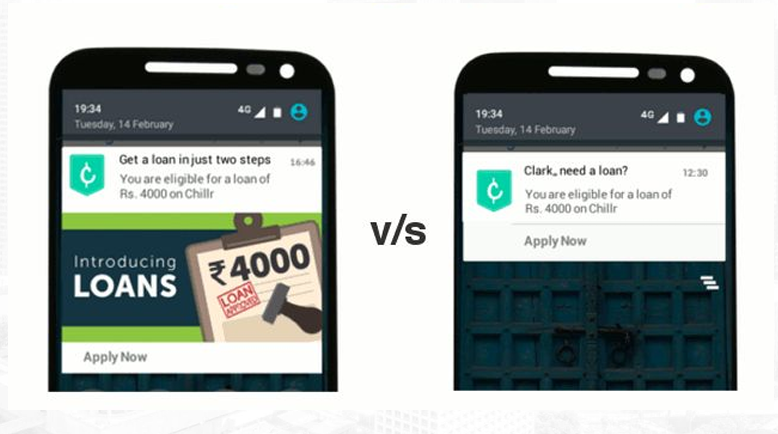

Mengurangi gambar, ternyata mengurangi CTR (ctr treatment (11.9) lebih rendah daripada ctr control (12.04))

(0.118, 0.1205)

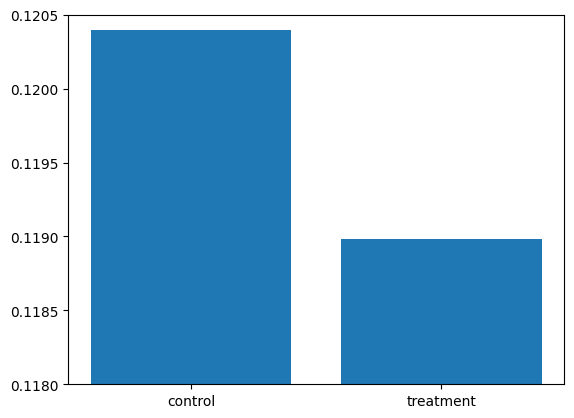

In [30]:
x = ['control', 'treatment']
value = (ctr_control, ctr_treatment)
plt.bar(x, value)

plt.ylim(0.118, 0.1205)

## Langkah 3

In [31]:
success = [success_control, success_treatment]
obs = [obs_control, obs_treatment]

In [33]:
stats, pvalue = sp.proportions_ztest(success, obs)

In [34]:
print("P-value:", pvalue)

P-value: 0.23535903969304361


## Langkah 4

In [36]:
if pvalue >= 0.05:
    print("Terima H0 bahwa new design atau old design tidak memiliki perbedaan secara signifikan pada CTR")
else:
    print("Terima H1 bahwa new design atau old design memiliki perbedaan secara signifikan pada CTR")

Terima H0 bahwa new design atau old design tidak memiliki perbedaan secara signifikan pada CTR


Artinya mau pakek design lama atau design yang baru tetap sama, karena lebih dari batas resikonya. => Berarti tidak apa apa kalau kita rilis design yang baru (tidak ada gambar). Misal buat memudahkan user untuk tidak download gambar/efisiensi komputasi. **Secara statistik sama**